# Week 6 Lecture Notes: Lindholm Chapter 5 - Learning Parametric Models

## Contents

- [Scope for Week 6](#scope-for-week-6)
- [Learning goals for this notebook](#learning-goals-for-this-notebook)
- [Chapter 5 summary](#chapter-5-summary)
  - [Training objective as a proxy for generalisation](#training-objective-as-a-proxy-for-generalisation)
  - [Loss functions and likelihood-based models](#loss-functions-and-likelihood-based-models)
    - [Regression losses](#regression-losses)
    - [Binary-classification losses and margins](#binary-classification-losses-and-margins)
  - [Regularisation](#regularisation)
    - [L2 regularisation and weight decay](#l2-regularisation-and-weight-decay)
    - [L1 regularisation and lasso](#l1-regularisation-and-lasso)
    - [Implicit regularisation via early stopping](#implicit-regularisation-via-early-stopping)
  - [Parameter optimisation](#parameter-optimisation)
    - [Convex versus non-convex objectives](#convex-versus-non-convex-objectives)
    - [Gradient descent](#gradient-descent)
    - [Second-order and quasi-Newton methods](#second-order-and-quasi-newton-methods)
  - [Optimisation with large datasets](#optimisation-with-large-datasets)
    - [Mini-batches, epochs, and stochastic gradient descent](#mini-batches-epochs-and-stochastic-gradient-descent)
    - [Learning-rate schedules and adaptive variants](#learning-rate-schedules-and-adaptive-variants)
  - [Hyperparameter optimisation](#hyperparameter-optimisation)
- [Exam-oriented takeaways](#exam-oriented-takeaways)
- [Past exam questions (2023-2025)](#past-exam-questions-2023-2025)
- [Toy example 1: comparing common loss functions](#toy-example-1-comparing-common-loss-functions)
- [Toy example 2: gradient descent and learning rate](#toy-example-2-gradient-descent-and-learning-rate)
- [Toy example 3: ridge regularisation on high-degree polynomial regression](#toy-example-3-ridge-regularisation-on-high-degree-polynomial-regression)
- [Week 6 wrap-up](#week-6-wrap-up)
- [Sources used](#sources-used)

## Scope for Week 6

- Topic: learning parametric models.
- Important concepts: optimisation, loss functions, regularisation.
- Algorithms and methods: gradient descent, stochastic gradient descent, mini-batches, Newton and quasi-Newton methods, validation-based hyperparameter tuning.
- Reading: [Lindholm (2022), Chapter 5](../../references/main-text-book-machine-learning-lindholm-2022.pdf).
- Prac alignment: Week 6 practical focuses on performance and loss functions; demos continue this week.
- Schedule note: the course summary flags the Good Friday public holiday in Week 6.
- Source note: the secondary MATLAB notes referenced by the skill were not present locally in `references/`, so these base notes are built from the course summary, Lindholm Chapter 5, and the indexed exam materials only.

## Learning goals for this notebook

1. Explain why training a parametric model is formulated as an optimisation problem, while remembering that the real target is generalisation on unseen data.
2. Distinguish the main loss functions and regularisation methods in Chapter 5, including what behaviour they encourage and what can go wrong.
3. Connect learning rates, SGD, explicit regularisation, and validation-based tuning to the style of questions that have appeared in recent COMP4702 exams.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 4702
random.seed(SEED)
np.random.seed(SEED)
plt.rcParams["figure.dpi"] = 120

print(f"Seed set to {SEED}")

Seed set to 4702


## Chapter 5 summary

Chapter 5 is where Week 4's parametric models become trainable beyond the small set of cases with a closed-form solution. The main exam-level questions are:

- what objective is being minimised,
- how the parameters are updated,
- what role the loss function plays, and
- how overfitting is controlled.

### Training objective as a proxy for generalisation

For a parametric model $f_{\boldsymbol{\theta}}(\mathbf{x})$, Lindholm writes learning as minimising a training-set cost function:

$$
\hat{\boldsymbol{\theta}} = \arg\min_{\boldsymbol{\theta}} \frac{1}{n} \sum_{i=1}^{n} L\bigl(y_i, f_{\boldsymbol{\theta}}(\mathbf{x}_i)\bigr). \qquad (5.4)
$$

This is **not** the true objective we care about. The real goal is low prediction error on unseen data:

$$
\hat{\boldsymbol{\theta}} = \arg\min_{\boldsymbol{\theta}} E_{\text{new}}(\boldsymbol{\theta}). \qquad (5.5)
$$

The important conceptual step is:

- the training objective is only a **proxy** for generalisation,
- fitting the training set more accurately does not automatically mean a better model,
- optimisation and statistics interact: there is no point solving the training objective more accurately than the data justifies.

Three Week 6 consequences follow from this:

1. **Loss function is a design choice.** You are free to train with a loss that is different from the error metric used for evaluation, as long as it is a useful proxy.
2. **Optimisation accuracy is not the whole story.** A numerically perfect minimiser of the training cost can still generalise badly.
3. **Early stopping makes sense.** The best validation performance can happen before the optimiser reaches the minimum of the training cost.

This is also the cleanest place to separate:

- **objective**: learn parameters that give a useful predictor,
- **optimisation**: choose an algorithm that moves $\boldsymbol{\theta}$ toward a good solution,
- **failure modes**: overfitting, poor loss choice, bad learning rate, or a model class that is too rigid or too flexible.

### Loss functions and likelihood-based models

The loss function determines what counts as a "bad prediction" during training. Combined with a model class, it effectively defines the learning problem.

#### Regression losses

For regression, Chapter 5 compares several losses.

**Squared error**

$$
L(y, \hat{y}) = (\hat{y} - y)^2. \qquad (5.6)
$$

- Default for linear regression.
- Convenient mathematically because it gives the normal equations in the linear case.
- Equivalent to maximum likelihood under **Gaussian noise**.
- Weakness: not robust to outliers because large residuals are squared.

**Absolute error**

$$
L(y, \hat{y}) = |\hat{y} - y|. \qquad (5.7)
$$

- More robust to outliers than squared error.
- Corresponds to a **Laplace-noise** assumption rather than Gaussian noise.
- Penalises large errors linearly rather than quadratically.

**Huber loss**

- Quadratic near zero, linear in the tails.
- Useful when you want squared-error behaviour for small residuals but less outlier sensitivity for large residuals.

**$\epsilon$-insensitive loss**

$$
L(y, \hat{y}) =
\begin{cases}
0 & \text{if } |\hat{y} - y| < \epsilon, \\
|\hat{y} - y| - \epsilon & \text{otherwise.}
\end{cases}
\qquad (5.9)
$$

- Introduces a tolerance band around the target.
- Important later for support vector regression.

What to remember:

- squared error is the easiest to optimise in basic regression,
- absolute and Huber losses are better when outliers matter,
- the loss encodes a modelling assumption, not just a numerical convenience.

#### Binary-classification losses and margins

For binary classification, Lindholm rewrites many losses in terms of the **margin**.
If the classifier is written as

$$
\hat{y}(\mathbf{x}) = \operatorname{sign}\{f(\mathbf{x})\}, \qquad (5.12)
$$

then the margin for a point $(\mathbf{x}, y)$ is

$$
y \, f(\mathbf{x}).
$$

Interpretation:

- positive margin: correct classification,
- negative margin: incorrect classification,
- small positive margin: correct, but close to the decision boundary,
- large positive margin: correct with confidence.

**Misclassification loss**

$$
L(y, \hat{y}) = \mathbb{I}\{\hat{y} \neq y\}. \qquad (5.10)
$$

- Natural as an evaluation metric.
- Bad as a training objective because it is piecewise constant and not gradient-friendly.

**Cross-entropy / logistic loss**

For probability model $g(\mathbf{x}) = p(y=1\mid \mathbf{x})$:

$$ 
L(y, g(\mathbf{x})) =
\begin{cases}
-\ln g(\mathbf{x}) & \text{if } y = 1, \\
-\ln(1-g(\mathbf{x})) & \text{if } y = -1.
\end{cases}
\qquad (5.11)
$$

Equivalently, in margin form:

$$
L(y f(\mathbf{x})) = \ln\bigl(1 + e^{-y f(\mathbf{x})}\bigr). \qquad (5.13)
$$

- Natural for logistic regression.
- Derived from maximum likelihood.
- Gives a smooth optimisation problem.
- Supports probability interpretation.

**Exponential loss**

$$
L(y f(\mathbf{x})) = e^{-y f(\mathbf{x})}. \qquad (5.15)
$$

- Important later for AdaBoost.
- Sensitive to outliers because it grows very fast for large negative margins.

**Hinge loss**

$$
L(y f(\mathbf{x})) =
\begin{cases}
1 - y f(\mathbf{x}) & \text{if } y f(\mathbf{x}) \le 1, \\
0 & \text{otherwise.}
\end{cases}
\qquad (5.16)
$$

- Important for support vector classification.
- Encourages a margin of at least 1.
- Downside: the learned score is not directly a calibrated class probability.

**Squared hinge** and **Huberised squared hinge**

- These keep the support-vector-style margin idea,
- but change the robustness/probability trade-off.

The practical Week 6 lesson is:

- evaluate classification models with misclassification-style measures when appropriate,
- but train them with a smoother and more informative loss such as cross-entropy or hinge-like losses.

### Regularisation

Regularisation exists because a flexible parametric model can fit training data too well.
The core idea is:

- prefer a simpler parameter vector unless the data strongly supports complexity,
- trade some training fit for better generalisation.

Lindholm distinguishes **explicit** and **implicit** regularisation.

The general explicit form is

$$
\hat{\boldsymbol{\theta}} = \arg\min_{\boldsymbol{\theta}} J(\boldsymbol{\theta}; X, \mathbf{y}) + \lambda R(\boldsymbol{\theta}). \qquad (5.26)
$$

This has three moving parts:

1. the original cost function $J$,
2. a regularisation term $R(\boldsymbol{\theta})$,
3. a hyperparameter $\lambda$ controlling the trade-off.

#### L2 regularisation and weight decay

For linear regression, Lindholm writes:

$$
\hat{\boldsymbol{\theta}} = \arg\min_{\boldsymbol{\theta}} \frac{1}{n}\|X\boldsymbol{\theta} - \mathbf{y}\|_2^2 + \lambda \|\boldsymbol{\theta}\|_2^2. \qquad (5.22)
$$

This is:

- **L2 regularisation**,
- **ridge regression**,
- also called **weight decay** in neural-network language.

Key effects:

- pushes parameter values toward zero,
- lowers model flexibility,
- often improves generalisation,
- gives a unique solution for linear regression when $\lambda > 0$.

For linear regression the regularised normal equations are

$$
(X^\top X + n\lambda I)\hat{\boldsymbol{\theta}} = X^\top \mathbf{y}, \qquad (5.23)
$$

so the closed-form solution becomes

$$
\hat{\boldsymbol{\theta}} = (X^\top X + n\lambda I)^{-1}X^\top \mathbf{y}. \qquad (5.24)
$$

Exam-level memory point:

- if you see $\lambda \|\boldsymbol{\theta}\|_2^2$, then $\lambda$ is the regularisation hyperparameter and the method is ridge / L2 / weight decay.

#### L1 regularisation and lasso

Replacing the L2 norm with the L1 norm gives:

$$
\hat{\boldsymbol{\theta}} = \arg\min_{\boldsymbol{\theta}} \frac{1}{n}\|X\boldsymbol{\theta} - \mathbf{y}\|_2^2 + \lambda \|\boldsymbol{\theta}\|_1. \qquad (5.25)
$$

This is **L1 regularisation** or **LASSO**.

Important difference from L2:

- L2 tends to make many parameters small,
- L1 tends to make some parameters exactly zero.

So L1 acts like a crude feature-selection mechanism by switching some inputs off completely.

#### Implicit regularisation via early stopping

Not all regularisation comes from changing the cost function.

**Early stopping** means:

- train with an iterative optimiser,
- monitor hold-out or validation error,
- stop when validation performance stops improving.

Why it works:

- training cost often keeps decreasing,
- validation error may decrease at first and then increase due to overfitting,
- the best generalising model may occur before the optimiser reaches the minimum of the training objective.

This matters especially for:

- logistic regression trained iteratively,
- neural networks,
- any large flexible model where overfitting can emerge during optimisation.

### Parameter optimisation

Week 6 is not only about defining the cost function; it is also about solving the optimisation problem efficiently.

#### Convex versus non-convex objectives

Convexity matters because a convex objective has:

- one global minimum,
- no other local minima.

Examples from this part of the course:

- linear regression: convex,
- logistic regression: convex,
- deep neural networks: non-convex.

Consequences:

- for convex objectives, a converged gradient-based method is much easier to trust,
- for non-convex objectives, initialisation and optimisation path matter because different runs can end at different local minima or saddle points.

#### Gradient descent

The gradient gives the direction of steepest increase of the objective, so the **negative** gradient gives the steepest local decrease.

Gradient descent updates parameters as

$$
\boldsymbol{\theta}^{(t+1)} = \boldsymbol{\theta}^{(t)} - \gamma \nabla_{\boldsymbol{\theta}} J\bigl(\boldsymbol{\theta}^{(t)}\bigr). \qquad (5.31)
$$

where $\gamma > 0$ is the **learning rate** or **step size**.

This single equation explains several exam questions:

- $\boldsymbol{\theta}^{(t)}$ means the current parameter estimate at iteration $t$,
- the gradient term says how the objective changes locally,
- the learning rate controls the size of the step.

What can go wrong:

- **too small $\gamma$**: the cost decreases very slowly,
- **too large $\gamma$**: the updates overshoot, oscillate, or diverge,
- **reasonable $\gamma$**: the cost falls steadily.

This is exactly the idea tested in [2024 exam PDF](../../references/2024_COMP4702_exam.pdf) Part A Question 5 and [2025 exam PDF](../../references/2025_COMP4702_exam.pdf) Part B Question 6.

#### Second-order and quasi-Newton methods

Gradient descent uses first-order information only.
Newton-style methods also use second-order information through the Hessian:

$$
\boldsymbol{\theta}^{(t+1)} =
\boldsymbol{\theta}^{(t)} -
\bigl[\nabla_{\boldsymbol{\theta}}^2 J(\boldsymbol{\theta}^{(t)})\bigr]^{-1}
\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta}^{(t)}). \qquad (5.34)
$$

Why they matter:

- can converge much faster near a well-behaved minimum,
- but require more structure and more computation,
- naive Newton steps can be unstable in non-convex settings.

The textbook therefore discusses:

- **trust region Newton methods**,
- **quasi-Newton methods** such as BFGS and L-BFGS.

For COMP4702 exam prep, the high-level idea is enough:

- first-order methods use gradients,
- second-order methods use curvature,
- trust-region variants try to keep the step in a region where the local approximation is reliable.

### Optimisation with large datasets

With large $n$, computing the full gradient each iteration can be expensive in both time and memory.
Chapter 5 therefore introduces subsampling and large-dataset optimisation.

#### Mini-batches, epochs, and stochastic gradient descent

Instead of computing

$$
\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta}) =
\frac{1}{n}\sum_{i=1}^{n}\nabla_{\boldsymbol{\theta}}L(\mathbf{x}_i, y_i, \boldsymbol{\theta}), \qquad (5.36)
$$

over the whole dataset every step, we approximate the gradient using a **mini-batch**.

Definitions to know:

- **mini-batch**: a small subset of the training data used for one update,
- **epoch**: one complete pass through the training set,
- **SGD**: gradient-based training with noisy gradient estimates from subsamples.

Important details from the textbook:

- mini-batches should be shuffled and representative,
- class-sorted data should not be fed directly in order,
- one common implementation is: shuffle data, split into mini-batches, run one epoch, reshuffle, repeat.

Exam nuance:

- [2023 exam PDF](../../references/2023_COMP4702_exam.pdf) Part A Question 6 uses the strict MCQ phrasing where SGD means updating from a **single training example**,
- Lindholm Chapter 5 also uses **mini-batch SGD** as the practical large-dataset version.

So the safe COMP4702 memory rule is:

- full-batch GD: uses all training data,
- classical SGD: one example,
- common modern usage: mini-batches, often still called SGD.

#### Learning-rate schedules and adaptive variants

For standard batch gradient descent, a constant learning rate can work if chosen carefully.
For stochastic gradient descent, a constant learning rate causes the parameters to keep wandering because the gradient estimate contains noise.

The textbook therefore motivates a **decaying learning rate**:

- start larger to move quickly,
- reduce it gradually,
- sometimes cap it at a small positive value in practice.

Lindholm also notes common adaptive variants:

- momentum-style ideas,
- AdaGrad,
- RMSProp,
- Adam.

These methods use information from earlier gradients to stabilise and adapt the updates.
You do not need every implementation detail for a COMP4702 exam answer, but you should know the big picture:

- they are still gradient-based,
- they try to make SGD behave better,
- they are particularly useful in deep learning and large-scale optimisation.

### Hyperparameter optimisation

The model parameters $\boldsymbol{\theta}$ are not the only quantities that must be chosen.
A typical Week 6 hyperparameter is the regularisation strength $\lambda$.

The book's practical framing is:

- choose a candidate value of $\lambda$,
- train the model,
- evaluate hold-out or validation error,
- repeat across a grid of candidate values,
- pick the one with the smallest validation error.

This is **hyperparameter optimisation**, not parameter learning.

Key exam-ready points:

- the validation set is used to tune hyperparameters,
- the test set should be left untouched until the end,
- grid search is feasible for low-dimensional hyperparameters such as one scalar $\lambda$,
- Week 5 evaluation ideas still matter here because the target is validation performance, not raw training cost.

## Exam-oriented takeaways

Most likely Week 6 ideas to be assessed:

1. explain why minimising training loss is only a proxy for minimising unseen-data error,
2. distinguish loss function from evaluation metric,
3. identify the effect of the learning rate in gradient descent,
4. identify $\lambda$ as the regularisation hyperparameter,
5. explain the difference between L1 and L2 regularisation,
6. explain why early stopping acts like regularisation,
7. define mini-batch, epoch, and SGD clearly,
8. recognise that misclassification loss is intuitive for evaluation but awkward for optimisation.

Fast revision checklist:

- Can I write down the Week 6 training objective and state why it is only a proxy?
- Can I match squared error to Gaussian noise and absolute error to Laplace noise?
- Can I explain why hinge or cross-entropy is easier to optimise than misclassification loss?
- Can I say what happens if the learning rate is too small or too large?
- Can I explain why L2 is called weight decay and why L1 encourages sparsity?
- Can I explain the train/validation/test roles when tuning $\lambda$?

## Past exam questions (2023-2025)

These were selected using [exam_questions_2023_2025_by_week.csv](../../references/exam_questions_2023_2025_by_week.csv) and copied from [COMP4702_exams_2023_2025.md](../../references/COMP4702_exams_2023_2025.md).

### 2023 Part A, Question 6

Source: [2023 exam PDF](../../references/2023_COMP4702_exam.pdf)

- Which of the following correctly describes stochastic gradient descent (SGD)?
- (a) SGD computes the gradient of the objective function over the entire training set.
- (b) SGD updates the model parameters using the gradient plus a random noise term.
- (c) SGD computes the gradient of the objective function over a single training example.
- (d) SGD computes the gradient of the objective function over a random subset of the validation set.

Revision note: the exam bank's expected answer is **(c)**. Keep the modern mini-batch usage in mind, but memorise the exam's stricter contrast against full-batch gradient descent.

### 2024 Part A, Question 5

Source: [2024 exam PDF](../../references/2024_COMP4702_exam.pdf)

- Consider training a machine learning model using gradient descent. If the value of the learning rate parameter is not suitable, possible consequences are:
- (a) The cost function value decreases very slowly over iterations.
- (b) The cost function value rapidly increases over iterations.
- (c) The cost function value behaves randomly, jumping up and down with different values.
- (d) All of the above.

Revision note: the answer is **(d)**. This is the cleanest exam reminder that learning rate problems show up as slowness, instability, or divergence.

### 2024 Part A, Question 6

Source: [2024 exam PDF](../../references/2024_COMP4702_exam.pdf)

- A linear regression model is trained by solving the following optimisation problem:

$$
\hat{\theta} = \arg\min_{\theta} \frac{1}{n}\|X\theta - y\|_2^2 + \lambda\|\theta\|_2^2
$$

- In this equation, the regularisation hyperparameter is denoted by:
- (a) $\theta$
- (b) $n$
- (c) $2$
- (d) $\lambda$

Revision note: the answer is **(d)**. This is the standard Week 6 "spot the hyperparameter" question.

### 2025 Part A, Question 6

Source: [2025 exam PDF](../../references/2025_COMP4702_exam.pdf)

- A commonly used loss function in machine learning is given by:

$$
L(y, \hat{y}) = I\{\hat{y} \ne y\} =
\begin{cases}
0 & \text{if } \hat{y} = y, \\
1 & \text{if } \hat{y} \ne y.
\end{cases}
$$

- This is known as the:
- (a) Misclassification loss.
- (b) Mean squared error.
- (c) $\epsilon$-insensitive loss.
- (d) Cross-entropy loss.

Revision note: the answer is **(a)**. Important distinction: this is a common loss to define, but not usually the one you optimise directly with gradient methods.

### 2023 Part B, Question 4

Source: [2023 exam PDF](../../references/2023_COMP4702_exam.pdf)

The extracted markdown omits the figure itself, but the wording that remains is still useful:

- In the course textbook, the following Algorithm is presented:
- (a) In this pseudocode, what does $\theta^{(t)}$ represent? (2 marks)
- (b) In this pseudocode, what does $n$ represent? (2 marks)
- (c) In this pseudocode, what does $E$ represent? (2 marks)
- (d) Explain how the pseudocode in Figure 4 can be simplified if we want to describe (full batch) gradient descent (i.e. if $n_b = n$)? Refer to the line numbers and state which lines of code should be removed or modified in this case. (4 marks)

Revision note: be able to read optimisation pseudocode symbol-by-symbol, not just conceptually.

### 2025 Part B, Question 6

Source: [2025 exam PDF](../../references/2025_COMP4702_exam.pdf)

- Figure 5 (from the textbook) shows an illustration of gradient descent when different learning rate values are used.
- Using the example of training a feedforward neural network and Figure 5, explain briefly what the objective of gradient descent is and why it can be challenging to find a suitable value for the learning rate hyperparameter. (5 marks)

Revision note: this is a short-answer version of the same learning-rate idea as 2024-A-5, so practise answering it in plain English without relying on a figure.

### 2024 Part B, Question 5 (secondary relevance)

Source: [2024 exam PDF](../../references/2024_COMP4702_exam.pdf)

- Figure 5 is taken for a machine learning textbook and shows some experimental results comparing neural networks trained with and without weight decay.
- (a) What do the results in Figure 5 show regarding the effect of weight decay? (3 marks)
- (b) What do the results in Figure 5 show regarding the effect of varying the number of hidden units? (4 marks)

Revision note: this sits primarily in Week 7, but it is a good reminder that **weight decay = L2 regularisation** and that regularisation shows up again in neural-network training.

## Toy example 1: comparing common loss functions

This example plots a few of the Week 6 losses so the geometry is visible.

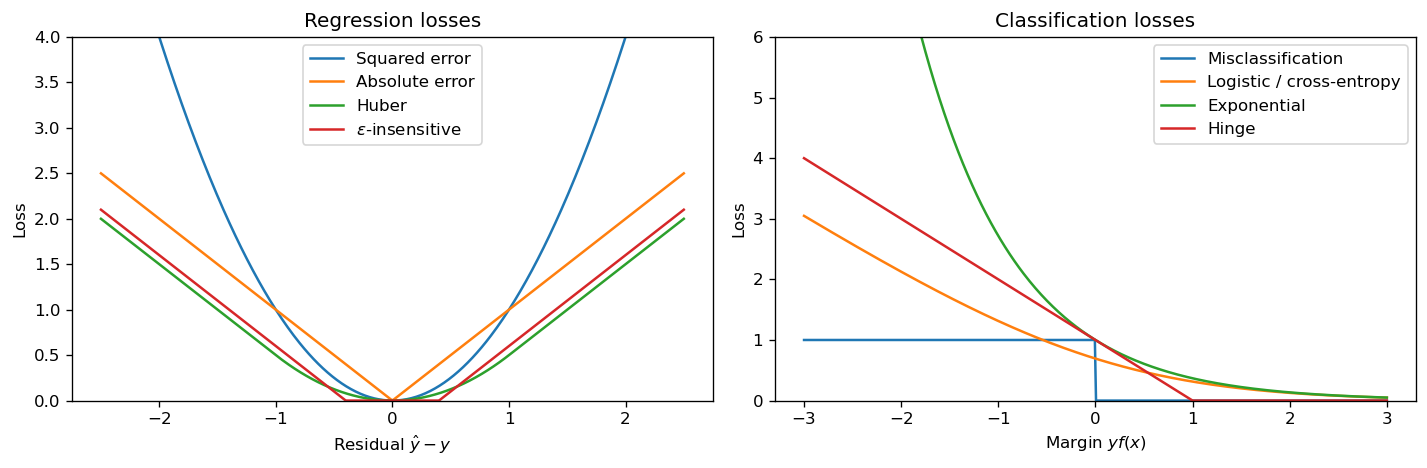

Squared error grows fastest for large residuals, so it is least robust to outliers.
Hinge loss becomes zero once the margin reaches 1, while logistic loss keeps rewarding larger margins more smoothly.


In [2]:
residual = np.linspace(-2.5, 2.5, 500)
margin = np.linspace(-3.0, 3.0, 500)
eps = 0.4

# Regression losses
squared = residual**2
absolute = np.abs(residual)
huber = np.where(np.abs(residual) <= 1.0, 0.5 * residual**2, np.abs(residual) - 0.5)
eps_insensitive = np.maximum(0.0, np.abs(residual) - eps)

# Classification losses as functions of margin
misclassification = (margin < 0).astype(float)
logistic = np.log1p(np.exp(-margin))
exponential = np.exp(-margin)
hinge = np.maximum(0.0, 1.0 - margin)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(residual, squared, label="Squared error")
ax.plot(residual, absolute, label="Absolute error")
ax.plot(residual, huber, label="Huber")
ax.plot(residual, eps_insensitive, label=r"$\epsilon$-insensitive")
ax.set_title("Regression losses")
ax.set_xlabel(r"Residual $\hat{y} - y$")
ax.set_ylabel("Loss")
ax.set_ylim(0, 4)
ax.legend()

ax = axes[1]
ax.plot(margin, misclassification, label="Misclassification")
ax.plot(margin, logistic, label="Logistic / cross-entropy")
ax.plot(margin, exponential, label="Exponential")
ax.plot(margin, hinge, label="Hinge")
ax.set_title("Classification losses")
ax.set_xlabel(r"Margin $y f(x)$")
ax.set_ylabel("Loss")
ax.set_ylim(0, 6)
ax.legend()

plt.tight_layout()
plt.show()

print("Squared error grows fastest for large residuals, so it is least robust to outliers.")
print("Hinge loss becomes zero once the margin reaches 1, while logistic loss keeps rewarding larger margins more smoothly.")

## Toy example 2: gradient descent and learning rate

Use a simple 1D quadratic objective so the effect of the learning rate is obvious.

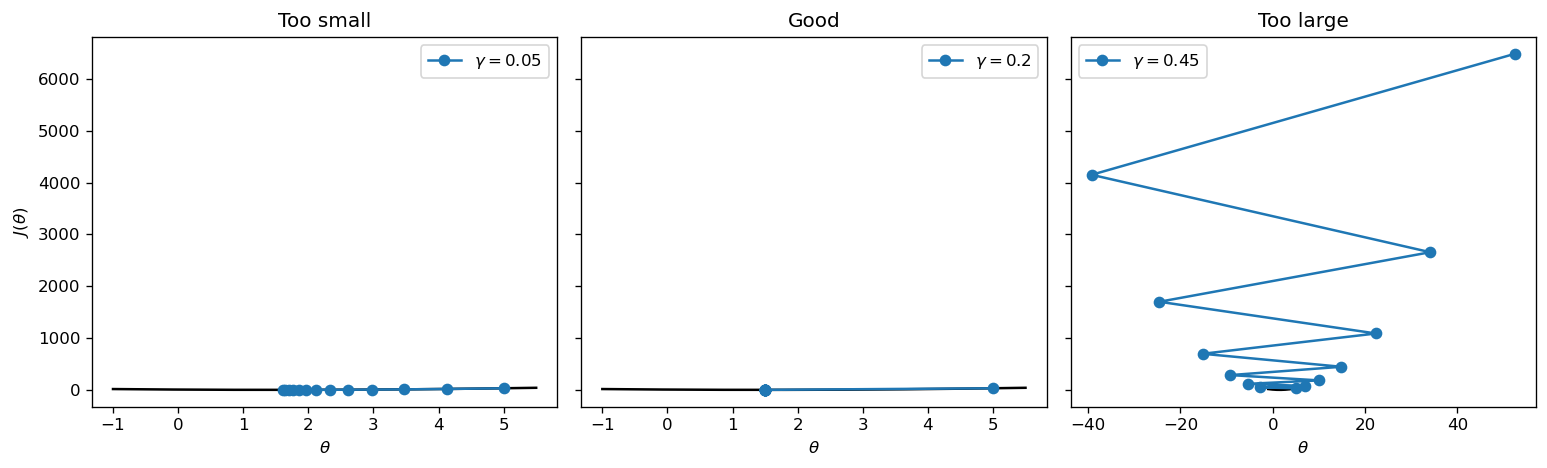

Too small  gamma=0.05 final theta= 1.611 final J= 0.2307
Good       gamma=0.20 final theta= 1.500 final J= 0.2000
Too large  gamma=0.45 final theta= 52.432 final J= 6485.2960


In [3]:
def objective(theta):
    return 2.5 * (theta - 1.5) ** 2 + 0.2


def gradient(theta):
    return 5.0 * (theta - 1.5)


def run_gradient_descent(theta0, gamma, steps):
    thetas = [theta0]
    values = [objective(theta0)]
    theta = theta0
    for _ in range(steps):
        theta = theta - gamma * gradient(theta)
        thetas.append(theta)
        values.append(objective(theta))
    return np.array(thetas), np.array(values)


theta0 = 5.0
steps = 12
learning_rates = {
    "Too small": 0.05,
    "Good": 0.20,
    "Too large": 0.45,
}

theta_grid = np.linspace(-1.0, 5.5, 400)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, (label, gamma) in zip(axes, learning_rates.items()):
    thetas, values = run_gradient_descent(theta0, gamma, steps)
    ax.plot(theta_grid, objective(theta_grid), color="black")
    ax.plot(thetas, values, "o-", label=fr"$\gamma={gamma}$")
    ax.set_title(label)
    ax.set_xlabel(r"$\theta$")
    ax.legend()

axes[0].set_ylabel(r"$J(\theta)$")
plt.tight_layout()
plt.show()

for label, gamma in learning_rates.items():
    thetas, values = run_gradient_descent(theta0, gamma, steps)
    print(f"{label:10s} gamma={gamma:.2f} final theta={thetas[-1]: .3f} final J={values[-1]: .4f}")

Interpretation:

- small $\gamma$ moves toward the minimum, but very slowly,
- a reasonable $\gamma$ converges quickly,
- a too-large $\gamma$ overshoots and becomes unstable.

## Toy example 3: ridge regularisation on high-degree polynomial regression

This example keeps the model deliberately flexible so that regularisation matters.

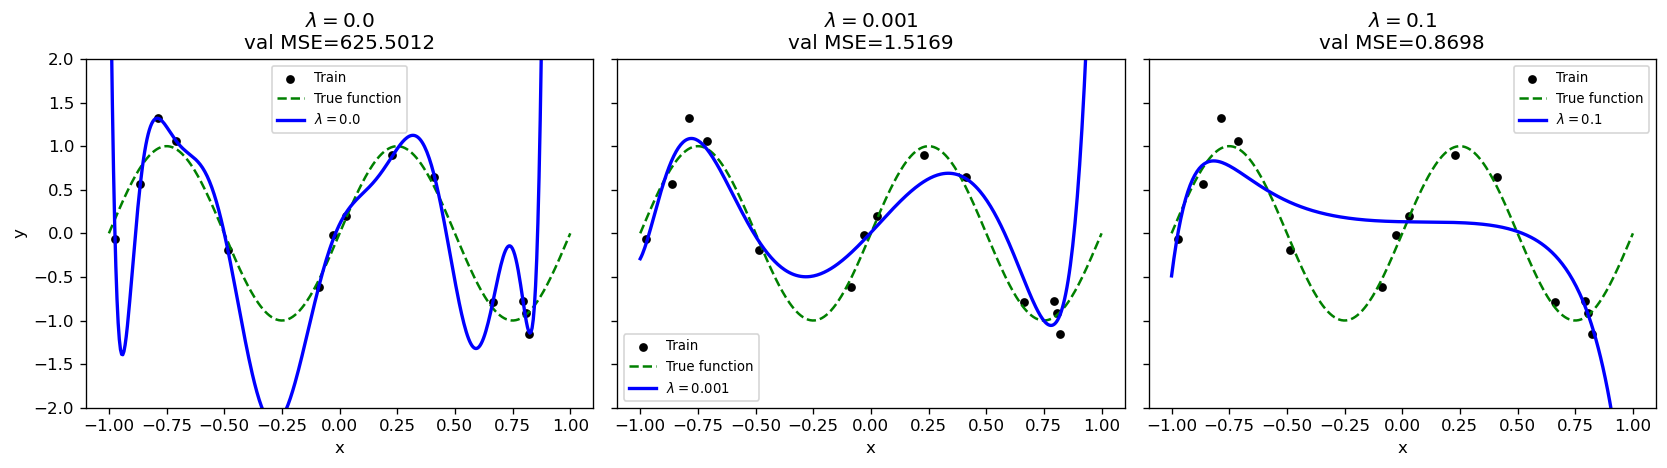

lambda    train_mse   val_mse   ||theta||_2
     0      0.0007   625.5012    2118.1712
 0.001      0.0430    1.5169       5.3181
   0.1      0.1815    0.8698       0.5905

Best lambda by hold-out MSE in this toy run: 0.1


In [4]:
rng = np.random.default_rng(SEED)


def true_function(x):
    return np.sin(2 * np.pi * x)


def design_matrix(x, degree):
    return np.column_stack([x**d for d in range(degree + 1)])


def standardise_from_train(X_train_raw, X_other_raw):
    X_train = X_train_raw.copy()
    X_other = X_other_raw.copy()

    mu = X_train[:, 1:].mean(axis=0)
    sigma = X_train[:, 1:].std(axis=0)
    sigma[sigma == 0] = 1.0

    X_train[:, 1:] = (X_train[:, 1:] - mu) / sigma
    X_other[:, 1:] = (X_other[:, 1:] - mu) / sigma
    return X_train, X_other


def ridge_fit(X, y, lam):
    if lam == 0.0:
        return np.linalg.lstsq(X, y, rcond=None)[0]
    eye = np.eye(X.shape[1])
    eye[0, 0] = 0.0  # do not regularise the intercept
    return np.linalg.solve(X.T @ X + X.shape[0] * lam * eye, X.T @ y)


degree = 12
x_train = np.sort(rng.uniform(-1.0, 1.0, 14))
y_train = true_function(x_train) + 0.15 * rng.normal(size=x_train.size)

x_val = np.linspace(-1.0, 1.0, 80)
y_val = true_function(x_val) + 0.15 * rng.normal(size=x_val.size)

X_train_raw = design_matrix(x_train, degree)
X_val_raw = design_matrix(x_val, degree)
X_train, X_val = standardise_from_train(X_train_raw, X_val_raw)

x_plot = np.linspace(-1.0, 1.0, 400)
X_plot_raw = design_matrix(x_plot, degree)
_, X_plot = standardise_from_train(X_train_raw, X_plot_raw)

lambdas = [0.0, 1e-3, 1e-1]
results = []

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, lam in zip(axes, lambdas):
    theta = ridge_fit(X_train, y_train, lam)
    y_hat_train = X_train @ theta
    y_hat_val = X_val @ theta
    y_hat_plot = X_plot @ theta

    train_mse = np.mean((y_hat_train - y_train) ** 2)
    val_mse = np.mean((y_hat_val - y_val) ** 2)
    weight_norm = np.linalg.norm(theta[1:])
    results.append((lam, train_mse, val_mse, weight_norm))

    ax.scatter(x_train, y_train, c="black", s=18, label="Train")
    ax.plot(x_plot, true_function(x_plot), "g--", linewidth=1.5, label="True function")
    ax.plot(x_plot, y_hat_plot, "b-", linewidth=2, label=fr"$\lambda={lam}$")
    ax.set_title(fr"$\lambda={lam}$" + "\n" + fr"val MSE={val_mse:.4f}")
    ax.set_xlabel("x")
    ax.set_ylim(-2.0, 2.0)
    ax.legend(fontsize=8)

axes[0].set_ylabel("y")
plt.tight_layout()
plt.show()

print("lambda    train_mse   val_mse   ||theta||_2")
for lam, train_mse, val_mse, weight_norm in results:
    print(f"{lam:>6g}   {train_mse:>9.4f}   {val_mse:>7.4f}   {weight_norm:>10.4f}")

best_lambda = min(results, key=lambda row: row[2])[0]
print(f"\nBest lambda by hold-out MSE in this toy run: {best_lambda}")

What to look for:

- $\lambda = 0$ usually fits training data most aggressively,
- moderate $\lambda$ often gives smaller validation error,
- larger $\lambda$ shrinks the parameter norm and makes the fit smoother.

That is exactly the Week 6 explicit-regularisation trade-off.

## Week 6 wrap-up

What to remember:

1. Parametric learning is written as optimisation of a training objective, but the real goal is low unseen-data error.
2. The loss function matters because it defines what the optimiser sees.
3. Squared error, absolute error, cross-entropy, hinge, and related losses are not interchangeable; they encode different assumptions and behaviour.
4. L2 regularisation, ridge regression, and weight decay are the same basic idea in different language.
5. L1 regularisation encourages sparsity.
6. Early stopping is regularisation even though the cost function itself is unchanged.
7. Gradient descent lives or dies by the learning rate.
8. SGD trades exact gradients for cheaper noisy updates, which is essential at scale.

What connects forward:

- Week 7 uses these optimisation and regularisation ideas directly for neural networks.
- Week 8 and later topics keep reusing loss choice, weight decay, mini-batches, and validation-based tuning.

## Sources used

1. [Course Summary Table, Semester 1 2026](../../references/CourseSummaryTable_v1_26.pdf)
2. [Lindholm, Chapter 5](../../references/main-text-book-machine-learning-lindholm-2022.pdf)
3. [Indexed exam questions by week](../../references/exam_questions_2023_2025_by_week.csv)
4. [Extracted exam text 2023-2025](../../references/COMP4702_exams_2023_2025.md)

Local-source note: `references/lecture_notes_matlab_2026_v1.pdf` was not present in this repo, so it was not used.